# Extract data + Spectrogram generation

We first get the full database and then extract the data, separating training and test data. From this we extract two pandas dataframes.

In [1]:
!pip install audformat opensmile audb scikit-learn torchinfo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.9/74.9 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 38.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.7/133.7 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.0/325.0 kB 33.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 271.3/271.3 kB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.8/93.8 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 99.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 707.4/707.4 kB 58.9 MB/s eta 0:00:00


In [2]:
import audb
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import torchvision.models as models
from torchvision import transforms
from torchvision.datasets import ImageFolder
import torch
import torchinfo

from PIL import Image
import json
import urllib.request

import torch
import torchaudio
import torchaudio.transforms as T

# Load the emodb database
db = audb.load("emodb")

Get:   emodb v2.0.0
Cache: /root/audb/emodb/2.0.0/d3b62a9b


In [3]:
# get the data, no ambiguous audios, separate train and test splits

train_data: pd.DataFrame = db["emotion.categories.train.gold_standard"].get().copy()
test_data: pd.DataFrame = db["emotion.categories.test.gold_standard"].get().copy()

From the audios given, we make them 3s long by padding or truncating them. Then, we calculate their spectrogram and add it to the dataframe to make it usable.

In [4]:
def truncate_or_pad(x, target_len):
    current_len = x.shape[1]

    if isinstance(x, torch.Tensor):
        if current_len > target_len:
            return x[:, :target_len]
        else:
            pad_size = target_len - current_len
            pad_shape = (1, pad_size)
            padding = torch.zeros(pad_shape, dtype=x.dtype, device=x.device)
            return torch.cat([x, padding], dim=1)


def compute_spectrogram(file_path):
    waveform, sample_rate = torchaudio.load(file_path)
    waveform = truncate_or_pad(waveform, sample_rate * 3)

    # 25ms windows every 10ms
    window_length = int(sample_rate * 0.025)  # 25ms frames
    hop_length = int(sample_rate * 0.010)  # 10ms hop

    mel_transform = T.MelSpectrogram(
        sample_rate=sample_rate,
        win_length=window_length,
        hop_length=hop_length,
        n_mels=64,
    )

    amp_to_db = T.AmplitudeToDB(stype="power", top_db=80)

    spec_db = amp_to_db(mel_transform(waveform)).squeeze(0)

    return spec_db


def add_spectrogram_col(datafram_data):
    spectrogram_list = []
    for file_path in datafram_data.index:
        spectrogram_list.append(compute_spectrogram(file_path))

    datafram_data.insert(1, "spectrogram", spectrogram_list)

Finally, we can verify the number of audios for each of the splits, and show some spectrograms we just computed.

In [5]:
print("Number of training audios: ", len(train_data))
print("Number of testing audios:  ", len(test_data))

# plt.imshow(
#     compute_spectrogram(train_data.index[1]).numpy(),
#     origin="lower",
#     aspect=301 / 64,
#     cmap="gray",
# )
# plt.axis("off")
# plt.show()
# plt.imshow(
#     compute_spectrogram(test_data.index[1]).numpy(),
#     origin="lower",
#     aspect=301 / 64,
#     cmap="gray",
# )
# plt.axis("off")
# plt.show()

Number of training audios:  304
Number of testing audios:   231


We create the function that will save the spectrograms as images so that it can be the input of the ResNet18 model

In [6]:
# Function to save a 224*224*3 image of a spectrogram, with the riht filename, for a given spectrogram


def make_spectrogram_image(input_path, output_path):
    # Compute spectrogram data
    spectrogram = compute_spectrogram(input_path)
    figure = plt.figure(figsize=(2.24, 2.24), dpi=100)
    axes = figure.add_axes([0, 0, 1, 1])
    axes.imshow(
        spectrogram.numpy(),
        origin="lower",
        aspect="auto",
        cmap="gray",
    )
    axes.axis("off")
    figure.savefig(
        output_path,
        dpi=100,
        pad_inches=0,
    )
    plt.close(figure)

We make all the spectrograms png files

In [7]:
if not os.path.exists("test_png"):
    os.makedirs("test_png")

if not os.path.exists("train_png"):
    os.makedirs("train_png")

for file_path in test_data.index:
    emotion = test_data.loc[file_path, "emotion"]
    if not os.path.exists(f"test_png/{emotion}"):
        os.makedirs(f"test_png/{emotion}")
    output_path = f"test_png/{emotion}/{file_path.split('/')[-1].split('.')[0]}.png"
    make_spectrogram_image(file_path, output_path)

for file_path in train_data.index:
    emotion = train_data.loc[file_path, "emotion"]
    if not os.path.exists(f"train_png/{emotion}"):
        os.makedirs(f"train_png/{emotion}")
    output_path = f"train_png/{emotion}/{file_path.split('/')[-1].split('.')[0]}.png"
    make_spectrogram_image(file_path, output_path)

## ResNet18 model configuration

In [8]:
import torch
import torch.nn as nn

# Import Model
weights = models.ResNet18_Weights.IMAGENET1K_V1
model = models.resnet18(weights=weights)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 176MB/s]


In [9]:
torchinfo.summary(model, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 1000]                 --
├─Conv2d: 1-1                            [1, 64, 112, 112]         9,408
├─BatchNorm2d: 1-2                       [1, 64, 112, 112]         128
├─ReLU: 1-3                              [1, 64, 112, 112]         --
├─MaxPool2d: 1-4                         [1, 64, 56, 56]           --
├─Sequential: 1-5                        [1, 64, 56, 56]           --
│    └─BasicBlock: 2-1                   [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-1                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-2             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-3                    [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-4                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-5             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-6                    [1, 64, 56, 56]           --
│

### Modify the model to fit our needs

With frozen backbone, we will fit a new fully connected head

In [10]:
# First, we freeze all the layers of the model, except for the last fully connected layer
for param in model.parameters():
    param.requires_grad = False

# then we create a new fc layer with only the number of classes we want (we have 7 emotions)
model.fc = nn.Linear(model.fc.in_features, 7)

### Prepare the datasets for training

In [11]:
# prepare the transforms
# as we expect the pngs to already be 224x224, we only need to convert them to tensors
# TODO keep normalizing them ? YES because it is not a from scratch model, and ResNet18 was trained on normalized images

transform_spectrogram = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

train_dataset = ImageFolder("train_png", transform=transform_spectrogram)
test_dataset = ImageFolder("test_png", transform=transform_spectrogram)

### Prepare the training settings

In [12]:
from torch.utils.data import DataLoader

batch_size = 32

train_loader = DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True, num_workers=2
)
test_loader = DataLoader(
    test_dataset, batch_size=batch_size, shuffle=False, num_workers=2
)

# Put the model on GPU if available

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print(device)
print(train_dataset.class_to_idx)

cuda
{'anger': 0, 'boredom': 1, 'disgust': 2, 'fear': 3, 'happiness': 4, 'neutral': 5, 'sadness': 6}


In [13]:
# Select the criterion and optimizer
criterion = (
    torch.nn.CrossEntropyLoss()
)  # according to the internet it is standard for multi-class
optimizer = torch.optim.Adam(
    model.fc.parameters(), lr=0.001
)  # According to the internet, Adam is easier to tune than SGD

# TODO modify learning rate to have a lower lr at the end of the training ?

### Finally, training the model

In [14]:
# The number of epochs can be adjuster here or we can launch the cell multiple times to continue the training
num_epochs = 20

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch + 1}/{num_epochs}")
    # Training
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        # Put data on the right device
        images = images.to(device)
        labels = labels.to(device)

        # Reset the gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass with optimising
        loss.backward()
        optimizer.step()

        # Compute the stats
        train_loss += loss.item() * images.size(0)
        predictions = outputs.argmax(dim=1)
        train_correct += (predictions == labels).sum().item()
        train_total += labels.size(0)

    # Evaluation
    model.eval()
    test_loss = 0.0
    test_correct = 0
    test_total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            test_loss += loss.item() * images.size(0)
            predictions = outputs.argmax(dim=1)
            test_correct += (predictions == labels).sum().item()
            test_total += labels.size(0)

    # Normalize the losses and accuracies
    train_loss /= train_total
    test_loss /= test_total
    train_accuracy = train_correct / train_total
    test_accuracy = test_correct / test_total

    print(
        f"Epoch {epoch + 1}/{num_epochs} | "
        f"Train loss: {train_loss:.4f} | "
        f"Train accuracy: {train_accuracy:.2%} | "
        f"Test loss: {test_loss:.4f} | "
        f"Test accuracy: {test_accuracy:.2%}"
    )

print("\nTraining complete!")


Epoch 1/20
Epoch 1/20 | Train loss: 1.9393 | Train accuracy: 22.37% | Test loss: 1.9541 | Test accuracy: 19.05%

Epoch 2/20
Epoch 2/20 | Train loss: 1.7387 | Train accuracy: 36.84% | Test loss: 1.8710 | Test accuracy: 24.68%

Epoch 3/20
Epoch 3/20 | Train loss: 1.5584 | Train accuracy: 47.04% | Test loss: 1.7929 | Test accuracy: 26.84%

Epoch 4/20
Epoch 4/20 | Train loss: 1.4229 | Train accuracy: 51.97% | Test loss: 1.6890 | Test accuracy: 36.36%

Epoch 5/20
Epoch 5/20 | Train loss: 1.3073 | Train accuracy: 57.24% | Test loss: 1.5277 | Test accuracy: 42.86%

Epoch 6/20
Epoch 6/20 | Train loss: 1.2404 | Train accuracy: 61.18% | Test loss: 1.4162 | Test accuracy: 46.75%

Epoch 7/20
Epoch 7/20 | Train loss: 1.1709 | Train accuracy: 62.83% | Test loss: 1.3530 | Test accuracy: 48.92%

Epoch 8/20
Epoch 8/20 | Train loss: 1.1399 | Train accuracy: 65.46% | Test loss: 1.2879 | Test accuracy: 51.52%

Epoch 9/20
Epoch 9/20 | Train loss: 1.0581 | Train accuracy: 70.07% | Test loss: 1.3051 | Test 

In [15]:
# When satisfied with a training, save the model
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "class_to_idx": train_dataset.class_to_idx,
    },
    "resnet18_emotion.pth",
)

# Also save only the fc layer weights:

torch.save(model.fc.state_dict(), "resnet18_emotion_fc.pth")

## Results and evaluation

In this section we use tools to evaluate the model


### Load a trained model

In [29]:
# We load the model we just trained


model = models.resnet18()
model.fc = nn.Linear(model.fc.in_features, 7)
model.load_state_dict(torch.load("resnet18_emotion.pth")["model_state_dict"])
model.eval()

print(torchinfo.summary(model, input_size=(1, 3, 224, 224)))

# Put the model to the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)


Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 7]                    --
├─Conv2d: 1-1                            [1, 64, 112, 112]         9,408
├─BatchNorm2d: 1-2                       [1, 64, 112, 112]         128
├─ReLU: 1-3                              [1, 64, 112, 112]         --
├─MaxPool2d: 1-4                         [1, 64, 56, 56]           --
├─Sequential: 1-5                        [1, 64, 56, 56]           --
│    └─BasicBlock: 2-1                   [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-1                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-2             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-3                    [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-4                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-5             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-6                    [1, 64, 56, 56]           --
│

In [34]:
# Get the prediction results on the entire database
import numpy as np
from sklearn.metrics import recall_score

# The evalution process is the same as the  evaluation process in training phase

def evaluate_model(loader, dataset_name):
    model.eval()
    all_preds = []
    all_labels = []
    total_loss = 0.0
    total_samples = 0

    with torch.no_grad(): # We are not training !
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            predictions = outputs.argmax(dim=1)

            all_preds.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            total_samples += labels.size(0)

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    avg_loss = total_loss / total_samples
    accuracy = (all_preds == all_labels).mean()
    # unweighted recall is equivalent to macro recall
    uar = recall_score(all_labels, all_preds, average='macro')

    print(f"=== {dataset_name} Evaluation ===")
    print(f"Loss: {avg_loss:.4f}")
    print(f"Accuracy: {accuracy:.2%}")
    print(f"UAR (Macro Recall): {uar:.2%}\n")

    return all_labels, all_preds

y_train, train_preds = evaluate_model(train_loader, "Train Dataset")
y_test, test_preds = evaluate_model(test_loader, "Test Dataset")

# And for the total database (test + train)

y_total = np.concatenate((y_train, y_test))
total_preds = np.concatenate((train_preds, test_preds))

total_accuracy = (total_preds == y_total).mean()
total_uar = recall_score(y_total, total_preds, average='macro')

print(f"=== Total Evaluation (not really meaningful) ===")
print(f"Accuracy: {total_accuracy:.2%}")
print(f"UAR (Macro Recall): {total_uar:.2%}\n")


=== Train Dataset Evaluation ===
Loss: 0.6138
Accuracy: 87.83%
UAR (Macro Recall): 86.30%

=== Test Dataset Evaluation ===
Loss: 1.1378
Accuracy: 53.25%
UAR (Macro Recall): 50.70%

=== Total Evaluation (not really meaningful) ===
Accuracy: 72.90%
UAR (Macro Recall): 70.02%



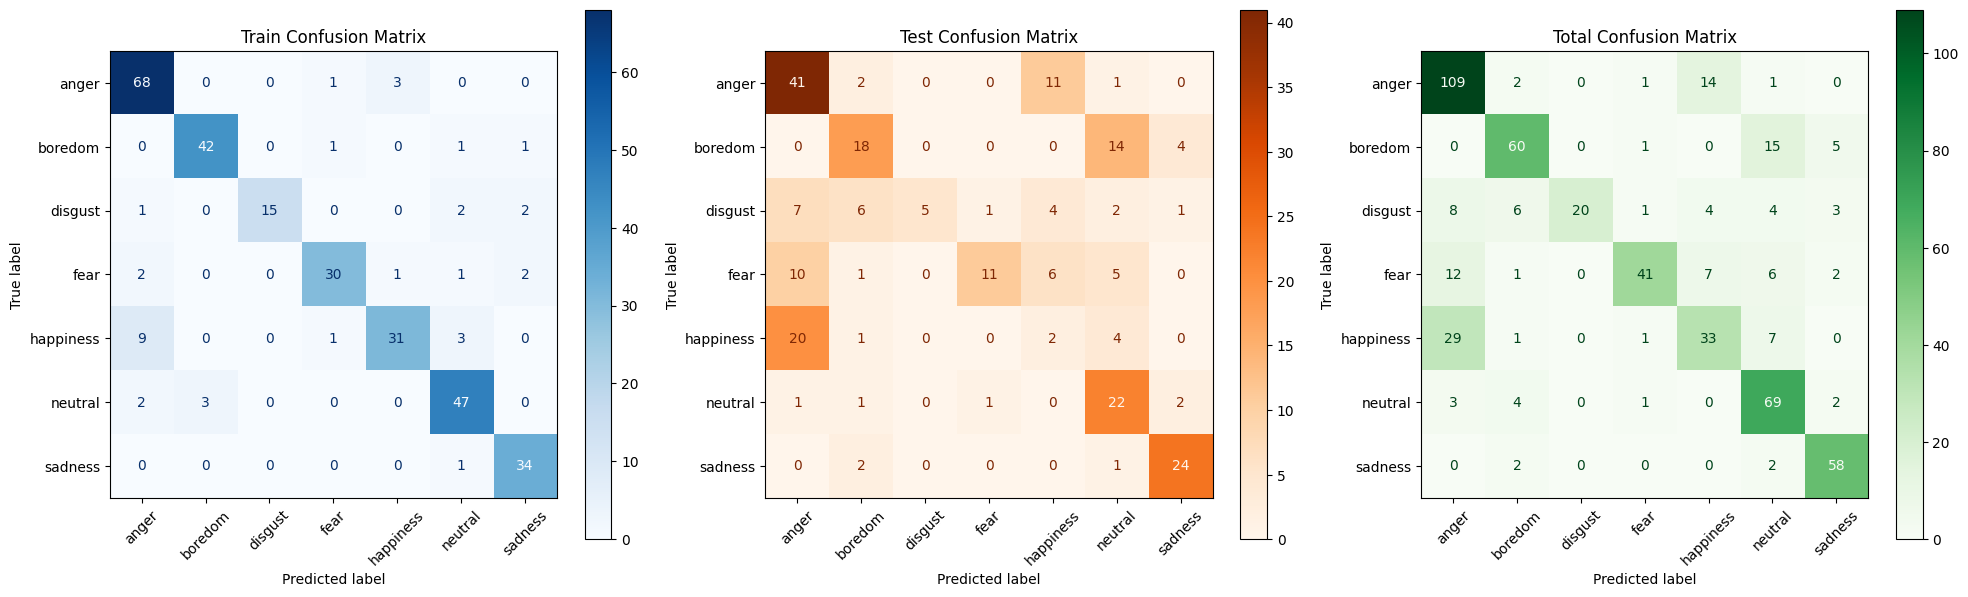

In [32]:
# Create confusion matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Get the classes
classes = list(train_dataset.class_to_idx.keys())

# Set up a multi-plot figure
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Train Confusion Matrix
cm_train = confusion_matrix(y_train, train_preds)
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=classes)
disp_train.plot(ax=axes[0], cmap='Blues', xticks_rotation=45)
axes[0].set_title("Train Confusion Matrix")

# Test Confusion Matrix
cm_test = confusion_matrix(y_test, test_preds)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=classes)
disp_test.plot(ax=axes[1], cmap='Oranges', xticks_rotation=45)
axes[1].set_title("Test Confusion Matrix")

# Total Confusion Matrix
cm_total = confusion_matrix(y_total, total_preds)
disp_total = ConfusionMatrixDisplay(confusion_matrix=cm_total, display_labels=classes)
disp_total.plot(ax=axes[2], cmap='Greens', xticks_rotation=45)
axes[2].set_title("Total Confusion Matrix")

plt.tight_layout()
plt.show()

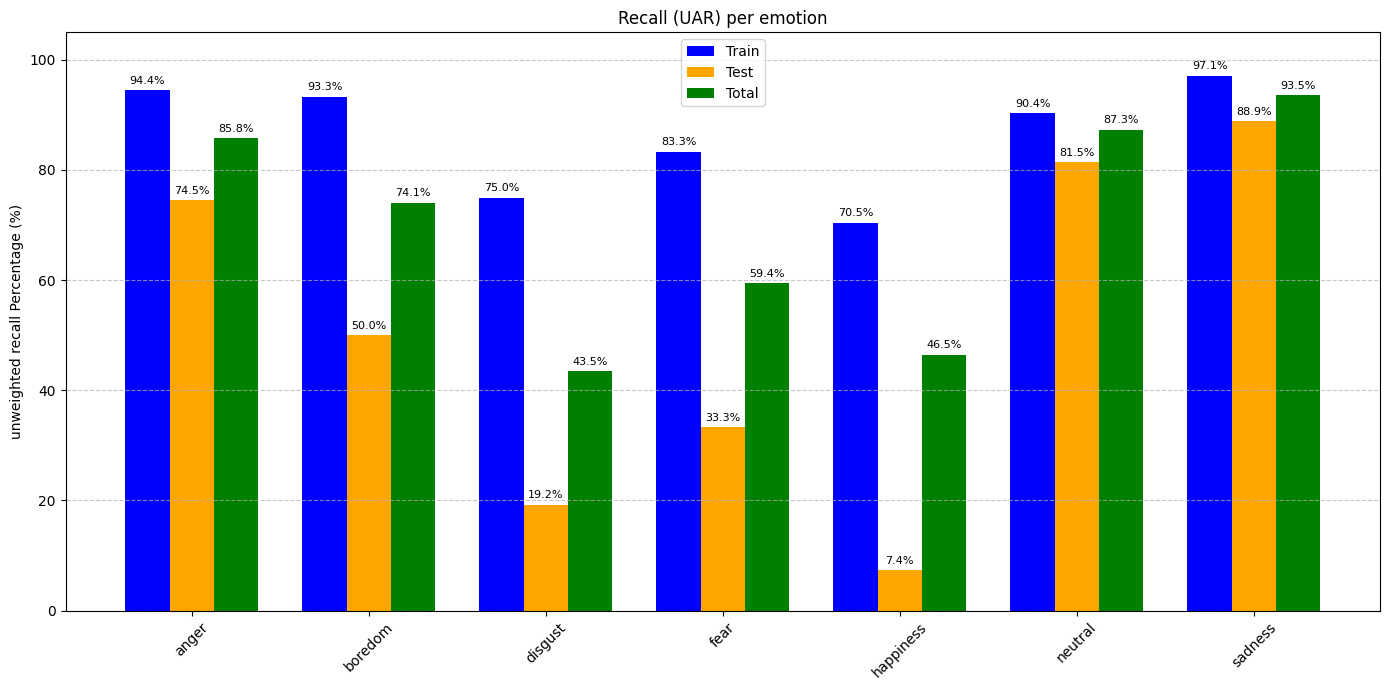

In [39]:
# Create the recall percentage per emotion, as in the prof. website

# recall_score with average=None returns the recall for each class in sorted order of class indices
recalls_train = recall_score(y_train, train_preds, average=None) * 100
recalls_test = recall_score(y_test, test_preds, average=None) * 100
recalls_total = recall_score(y_total, total_preds, average=None) * 100

x = np.arange(len(classes))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 7))

# Plot bars
rects1 = ax.bar(x - width, recalls_train, width, label='Train', color='blue')
rects2 = ax.bar(x, recalls_test, width, label='Test', color='orange')
rects3 = ax.bar(x + width, recalls_total, width, label='Total', color='green')

# Add details to the plot
ax.set_ylabel('unweighted recall Percentage (%)')
ax.set_title('Recall (UAR) per emotion')
ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=45)
ax.set_ylim(0, 105)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Function to attach a label on top of each bar
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.1f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

plt.tight_layout()
plt.show()